# EX6 — Tuning: a procedure, not an art

**What you will see**
* The tuning order **P → D → I** on the forward (position) loop of the mouse: one cell step, then a "hill".
* A **symptom quiz**: six step responses, each with one thing wrong. Name the symptom and the fix.
* The two things that bite everyone: **integrator windup** and the **noisy derivative**.
* Battery: the same gains at 8.4 V and 6.6 V.

| Symptom (step test) | Likely cause | Action |
|---|---|---|
| Slow, never quite reaches | Kp low; dead-band | ↑ Kp; minimum-PWM offset |
| Overshoots, then settles | Kp high, no D | ↑ Kd (or ↓ Kp a little) |
| Sustained oscillation | Kp far too high / Kd sign wrong | halve Kp; check Kd sign |
| Fast jitter / buzz in the PWM | D amplifying noise | filter D (`tf`), ↓ Kd |
| Reaches, then creeps past slowly | Integrator windup | clamp integrator; reset on setpoint change |
| Constant offset under load | No I / no feed-forward | small clamped Ki, or `Kff·v_set` |
| Fine at full battery, oscillates when low | Km changed | scale PWM by `V_nom / V_batt` |
| Changed after an unrelated code edit | Loop rate changed | fix `dt`; Ki, Kd scale with it |

### Clamping and windup

**Clamping:** simply capping the PID output to what the motor can physically take
(`u = max(umin, min(umax, u))`, e.g. ±255 PWM). Anything the maths asks for beyond that is thrown away.

**Windup:** what happens *without* protecting the integrator — if the output is already clamped (motor
maxed out) but the error is still pushing the same direction, `integ` keeps growing anyway. Once the error
finally reverses, the oversized integrator takes a long time to unwind, causing a big overshoot.

#### The AND rule (The fix)

**Two questions, both must say "yes" to pause the integrator:**

1. Is the output already maxed out? (`saturated`)
2. Is the error still pushing in the *same direction* that caused the max-out? (`e * u > 0` — same sign)

**Only if both are yes** → stop adding to `integ` (no point building up more "want" when the motor is already giving everything it has). (`if not (saturated and e*u > 0): integ += e*dt`)

**The moment either one flips to no** → resume integrating normally. Most importantly: if the error
*reverses* while still saturated, that's the integrator already unwinding — let it.

**Tiny example:** motor pinned at max PWM (255), error still positive → pause. Error flips negative
(target now behind you) → resume immediately, even though PWM is still 255 for that instant.

### Filtering the derivative
**Why filter the derivative:** the raw derivative `(e - e_prev)/dt` divides a tiny difference by a tiny
`dt` — any small noise/quantisation in `e` gets amplified into a huge, jittery number. A simple low-pass
filter (time constant `tf`) smooths that estimate before `Kd` multiplies it, trading a little responsiveness
for a lot less noise in the output.

In [1]:
from mouse_sim import *

cfg = Config()

## 1. The forward loop under test: 1-cell step at t = 0.05 s, a hill from t = 1.2 s
This is the EX3 forward loop on one wheel (counts as the measured variable), so the gains are in PWM/count.

In [2]:
def step_test(kp, ki, kd, tf=0.02, load=0.25, v_batt=8.4, deadband=None, noise_counts=0.0,
              anti_windup=True, hold=None, t_end=2.5, seed=0, d_on_meas=True):
    """Returns t, pos [counts], u [PWM], ref [counts].
    hold=(t0, t1): the wheel is physically blocked between t0 and t1 (shows windup)."""
    c = replace(cfg, v_batt=v_batt, deadband=cfg.deadband if deadband is None else deadband)
    rng = np.random.default_rng(seed)
    mot, enc = Motor(c), Encoder(c)
    pid = PID(kp, ki, kd, tf=tf, umin=-255, umax=255, d_on_measurement=d_on_meas)
    target = c.counts_per_cell
    t = np.arange(0, t_end, c.dt)
    pos, u, ref = np.zeros_like(t), np.zeros_like(t), np.zeros_like(t)
    for i, ti in enumerate(t):
        mot.load = load if ti >= 1.2 else 0.0
        ref[i] = target if ti >= 0.05 else 0.0
        meas = enc.counts + (rng.normal(0, noise_counts) if noise_counts else 0.0)
        e = ref[i] - meas
        if not anti_windup:                       # plain integrator for the windup demo
            pid.saturated = False
        u[i] = pid.update(e, c.dt, y=meas)
        blocked = hold is not None and hold[0] <= ti < hold[1]
        w = mot.step(0.0 if blocked else u[i]) if not blocked else 0.0
        if blocked:
            mot.omega = 0.0
        enc.update(w)
        pos[i] = enc.counts
    return t, pos, u, ref


def show(kp, ki, kd, title, fname=None, **kw):
    t, pos, u, ref = step_test(kp, ki, kd, **kw)
    target = cfg.counts_per_cell
    sel = t < 1.2
    ov = max(0.0, (pos[sel].max() - target) / target * 100)
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.5, 5), sharex=True)
    a1.plot(t, ref, "k--", lw=1); a1.plot(t, pos, lw=1.8)
    a1.axvline(1.2, color="tab:red", ls=":", lw=1)
    a1.set_ylabel("position [counts]"); a1.grid(alpha=0.3)
    a1.set_title(f"{title}\nKp={kp}, Ki={ki}, Kd={kd}  |  overshoot {ov:.1f} %, error at end {target-pos[-1]:+.0f} counts ({(target-pos[-1])/cfg.counts_per_mm:+.1f} mm)")
    a2.plot(t, u, lw=1.2, color="tab:orange"); a2.set_ylabel("PWM"); a2.set_ylim(-270, 270); a2.grid(alpha=0.3)
    a2.set_xlabel("time [s]"); fig.tight_layout()
    if fname: savefig(fig, fname)
    plt.show()

## 2. The procedure, step by step
### Step 1 — P only. Raise Kp until it is fast with a *little* overshoot.

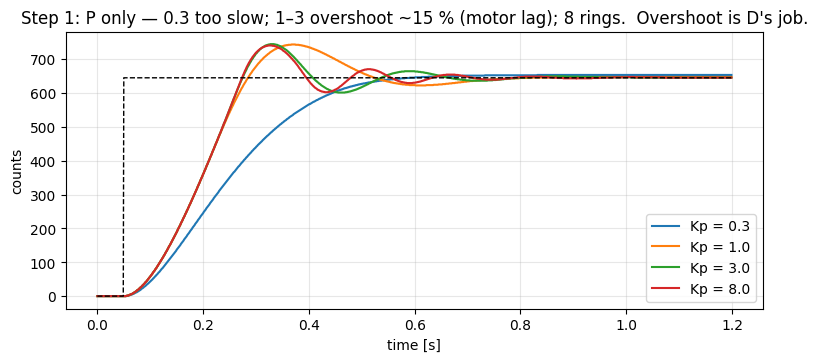

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for kp in (0.3, 1.0, 3.0, 8.0):
    t, pos, u, ref = step_test(kp, 0, 0, t_end=1.2)
    ax.plot(t, pos, label=f"Kp = {kp}")
ax.plot(t, ref, "k--", lw=1); ax.set_xlabel("time [s]"); ax.set_ylabel("counts"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Step 1: P only — 0.3 too slow; 1–3 overshoot ~15 % (motor lag); 8 rings.  Overshoot is D's job.")
savefig(fig, "ex06_step1_P.png"); plt.show()

### Step 2 — add D until the overshoot is gone (start around Kp/20). Too much → sluggish and noisy.

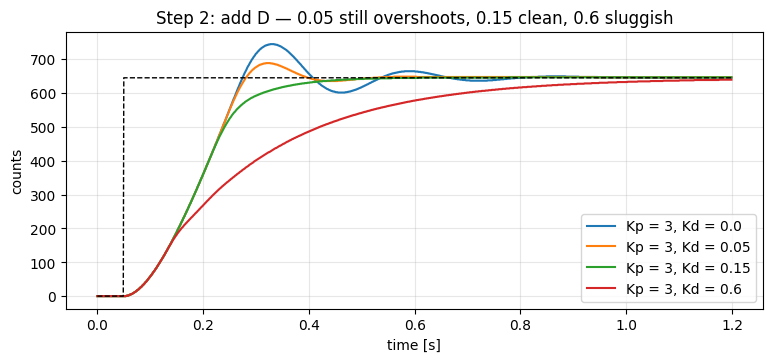

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for kd in (0.0, 0.05, 0.15, 0.6):
    t, pos, u, ref = step_test(3.0, 0, kd, t_end=1.2)
    ax.plot(t, pos, label=f"Kp = 3, Kd = {kd}")
ax.plot(t, ref, "k--", lw=1); ax.set_xlabel("time [s]"); ax.set_ylabel("counts"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Step 2: add D — 0.05 still overshoots, 0.15 clean, 0.6 sluggish")
savefig(fig, "ex06_step2_D.png"); plt.show()

### Step 3 — only if a steady offset remains under load, add a small, clamped Ki.

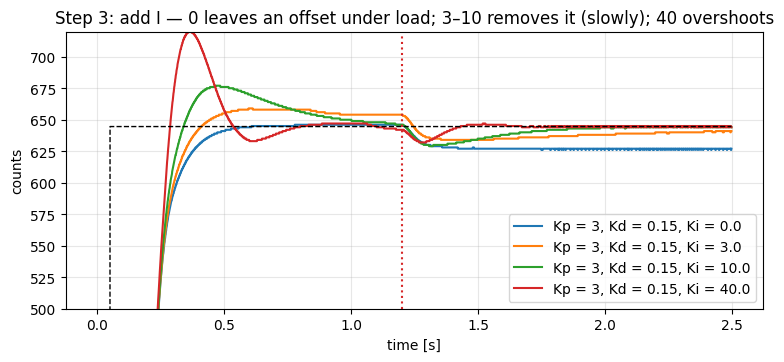

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for ki in (0.0, 3.0, 10.0, 40.0):
    t, pos, u, ref = step_test(3.0, ki, 0.15)
    ax.plot(t, pos, label=f"Kp = 3, Kd = 0.15, Ki = {ki}")
ax.plot(t, ref, "k--", lw=1); ax.axvline(1.2, color="tab:red", ls=":"); ax.set_ylim(500, 720)
ax.set_xlabel("time [s]"); ax.set_ylabel("counts"); ax.grid(alpha=0.3); ax.legend(loc="lower right")
ax.set_title("Step 3: add I — 0 leaves an offset under load; 3–10 removes it (slowly); 40 overshoots")
savefig(fig, "ex06_step3_I.png"); plt.show()

## 3. Symptom quiz — what is wrong with each one?
Show each figure, ask the chat, then reveal the answer in the markdown below it.

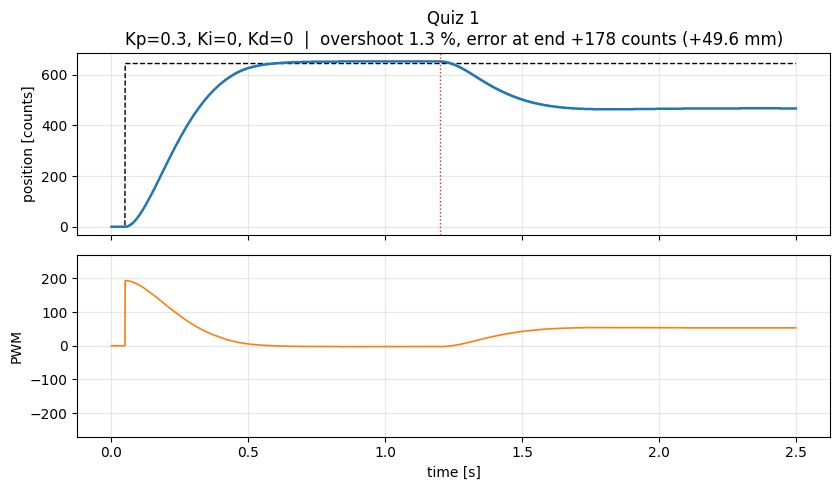

In [6]:
show(0.3, 0, 0, "Quiz 1", fname="ex06_quiz1.png")

**Answer 1:** slow, never reaches → **Kp too low**. Action: raise Kp.

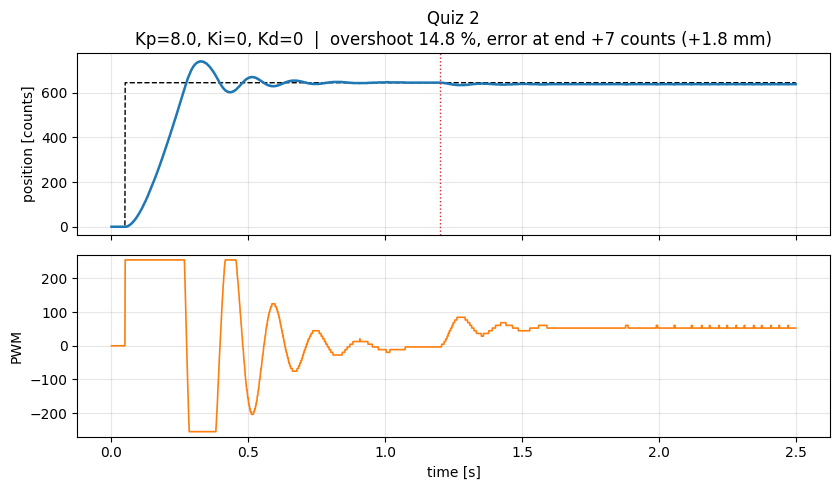

In [7]:
show(8.0, 0, 0, "Quiz 2", fname="ex06_quiz2.png")

**Answer 2:** rings for several cycles → **Kp too high, no damping**. Action: halve Kp *or* add Kd.

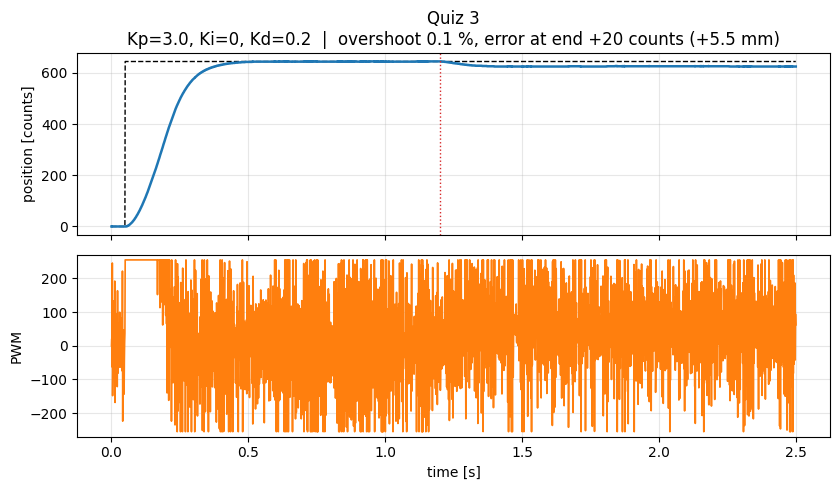

In [8]:
show(3.0, 0, 0.2, "Quiz 3", fname="ex06_quiz3.png", noise_counts=0.4, tf=0.0)

**Answer 3:** the position is fine but the PWM is buzzing → **derivative amplifying measurement noise**
(raw derivative, no filter). Action: filter D (`tf` ≈ 10–20 ms) and lower Kd.

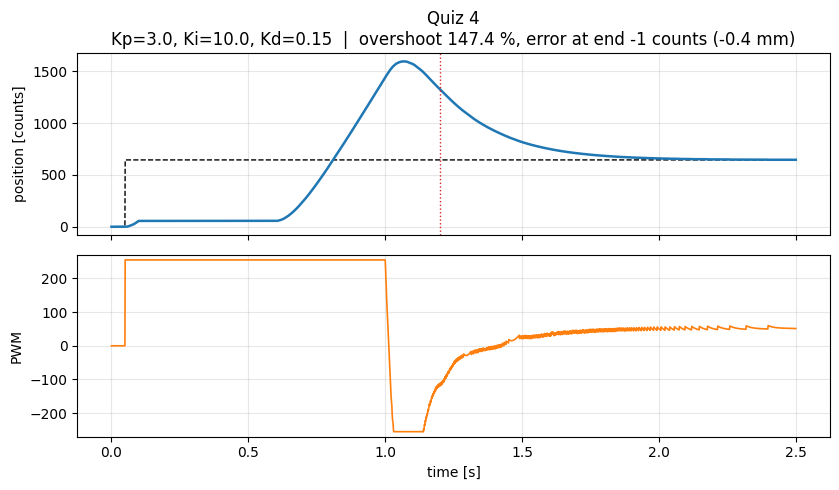

In [9]:
show(3.0, 10.0, 0.15, "Quiz 4", fname="ex06_quiz4.png", hold=(0.1, 0.6), anti_windup=False)

**Answer 4:** the wheel was blocked for 0.5 s; when released it overshoots massively and comes back slowly →
**integrator windup** (the integral kept growing while the PWM was already at 255). Action: stop integrating when
saturated (clamping) — that is the `if not (saturated and e pushes further)` line in `PID.update`.

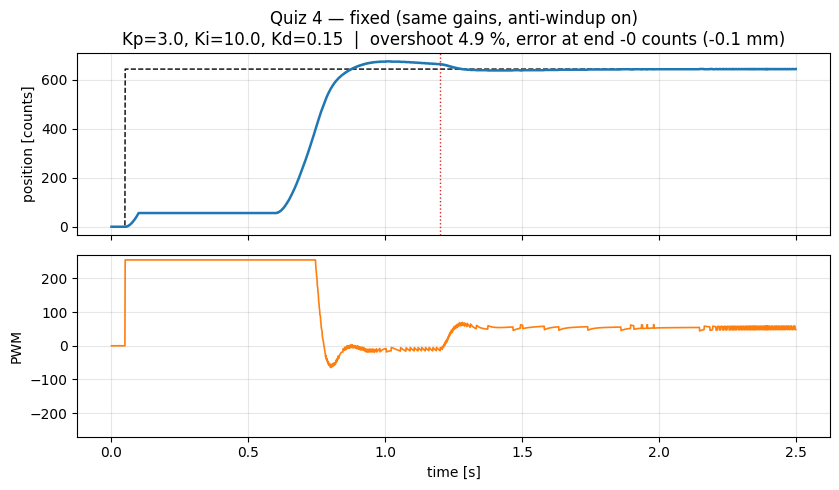

In [10]:
show(3.0, 10.0, 0.15, "Quiz 4 — fixed (same gains, anti-windup on)", fname="ex06_quiz4_fixed.png", hold=(0.1, 0.6), anti_windup=True)

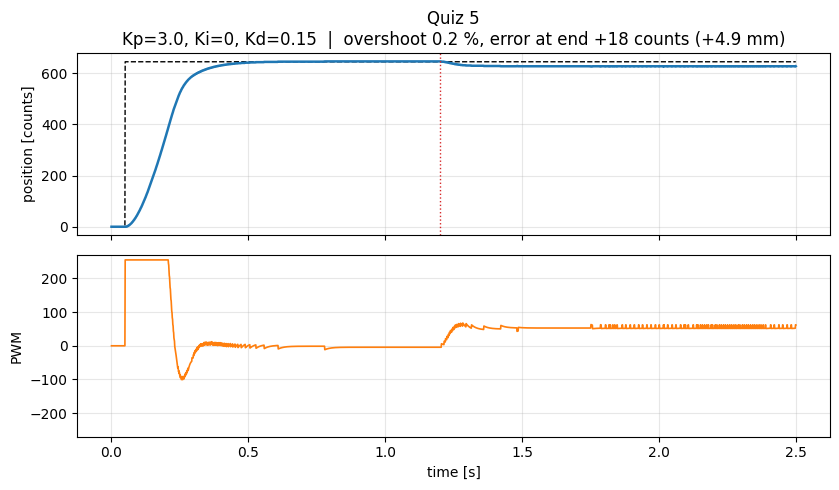

In [11]:
show(3.0, 0, 0.15, "Quiz 5", fname="ex06_quiz5.png")

**Answer 5:** clean step, then a **constant offset after the hill** → no integral action. Action: small clamped Ki
(or feed-forward if the load is predictable).

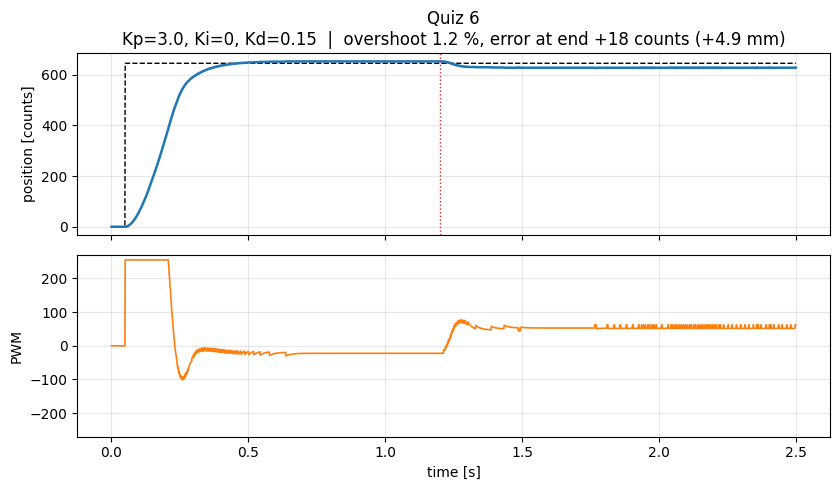

In [12]:
show(3.0, 0, 0.15, "Quiz 6", fname="ex06_quiz6.png", deadband=40)

**Answer 6:** it stops ~13 counts (4 mm) short and *stays* there, PWM sitting just under 40 → **dead-band / static
friction** (this motor needs 40 PWM to move at all, so `Kp·e` < 40 does nothing). Adding Ki would creep it in slowly
and overshoot on the next move; the right fix is a minimum-PWM offset in `set_motors` (or feed-forward).

## 4. Battery: tuned at 8.4 V, driven at 6.6 V

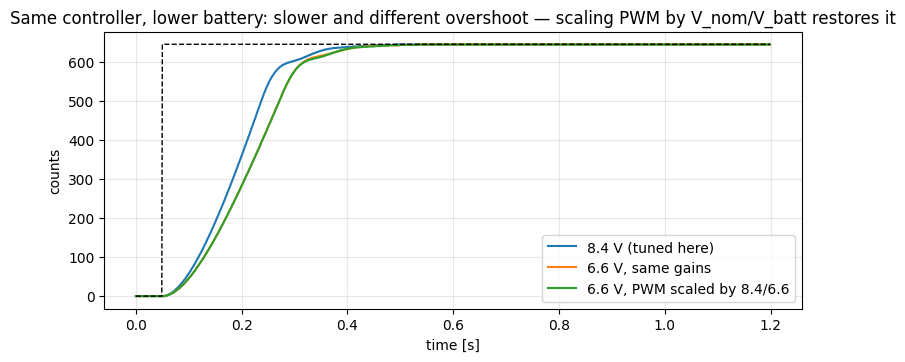

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for vb, lab in ((8.4, "8.4 V (tuned here)"), (6.6, "6.6 V, same gains"), (6.6, "6.6 V, PWM scaled by 8.4/6.6")):
    scale = 8.4 / 6.6 if "scaled" in lab else 1.0
    t, pos, u, ref = step_test(8.0 * scale, 0, 0.3 * scale, v_batt=vb, t_end=1.2)
    ax.plot(t, pos, label=lab)
ax.plot(t, ref, "k--", lw=1); ax.set_xlabel("time [s]"); ax.set_ylabel("counts"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Same controller, lower battery: slower and different overshoot — scaling PWM by V_nom/V_batt restores it")
savefig(fig, "ex06_battery.png"); plt.show()

**Talking point:** scaling the *output* by `V_nom / V_batt` is the same as scaling all three gains. One line, one ADC read.

## Try this
* Quiz 2 with `kd=0.3` — fixed. Quiz 2 with `kd=-0.3` (sign error) — worse. This is what "check the sign of Kd" means.
* `tf=0.05` in Quiz 3 — the buzz is gone but the response is now sluggish. There is a trade-off.

## On your mouse
* Log a step test to serial and plot it — you cannot tune what you cannot see.
* Tune the heading loop with the mouse on a stand (wheels free), the forward loop on the floor. Never inside the maze first.
* Keep a "safe gains" set (lower Kp, higher Kd) selectable by a button for competition day.